# Baseline v1 - Rider (Customer) Acceptance Prediction — Combined Pre + Post

**Câu hỏi:** Khách đặt cuốc — cuối cùng sẽ **ĐI** (`y_accept = 1`) hay **TỰ HUỶ** (`y_accept = 0`)?
Phân biệt 2 thời điểm huỷ bằng cờ `is_post_dispatch`:

- **Pre-Dispatch** (trước khi có tài xế): sẽ thấy ở phần 1.1, mọi đơn `is_post_dispatch = 0` đều
  có `y_accept = 0` — 100% "huỷ" theo đúng định nghĩa dữ liệu (đơn chưa từng được ghép tài xế).
- **Post-Dispatch** (sau khi có tài xế): trong nhóm `is_post_dispatch = 1`, vẫn còn ~10% đơn bị
  khách huỷ — phần khó dự đoán hơn, cần feature về ETA/giá/lịch sử khách.

**Khác với bản trước:** thay vì train riêng 1 model chỉ cho nhóm Post-Dispatch, bản này **gộp
toàn bộ đơn vào 1 model**, dùng `is_post_dispatch` làm 1 feature (**17 feature**: 10 PRE-numeric +
3 PRE-categorical + 4 POST — mới thêm `pickup_distance_km`, `payment_method` và `dist_center_km`,
xem phần 7.1). Vì `is_post_dispatch` gần như quyết định thẳng nhãn cho nhóm Pre, **luôn phải báo
cáo AUC riêng cho nhóm post-dispatch** bên cạnh AUC tổng (xem phần 7) — nếu không sẽ bị "thổi
phồng" bởi phần dễ đoán 100%.

Logic build feature nằm trong [`features.py`](features.py).

## 0 - Chuẩn bị


In [1]:
import sys, os, json
sys.path.insert(0, os.path.abspath('../src'))
import numpy as np, pandas as pd, lightgbm as lgb
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss
from sklearn.calibration import calibration_curve
import features as F
from train import PARAMS, TEST_DATE
from evaluation import evaluate
pd.set_option('display.width', 160)

## 1 - Hai file raw

In [2]:
orders_raw, customer_daily = F.load_raw('../data/raw')
print('orders_raw    ', orders_raw.shape, list(orders_raw.columns))
print('customer_daily', customer_daily.shape, list(customer_daily.columns))
print()
print('dup order_key trong orders_raw:', orders_raw.duplicated('order_key').sum())
print('dup (customer_key,stat_date) trong customer_daily:', customer_daily.duplicated(['customer_key', 'stat_date']).sum())
print('customer_key trong orders_raw khớp customer_daily:', f"{orders_raw.customer_key.isin(set(customer_daily.customer_key)).mean():.1%}")
print()
print('phủ ngày orders_raw    :', orders_raw.order_date.min().date(), '→', orders_raw.order_date.max().date())
print('phủ ngày customer_daily:', customer_daily.stat_date.min().date(), '→', customer_daily.stat_date.max().date())
orders_raw.head(3)

orders_raw     (280110, 20) ['order_key', 'customer_key', 'y_accept', 'is_post_dispatch', 'order_date', 'order_datetime', 'total_fee', 'surge_multiplier', 'trip_distance_km', 'travel_mode', 'vertical_name', 'service_name', 'pickup_province_name', 'pickup_latitude', 'pickup_longitude', 'is_schedule_order', 'payment_method', 'eta_seconds', 'pickup_distance_km', 're_dispatch_counts']
customer_daily (3360561, 5) ['customer_key', 'stat_date', 'n_orders', 'n_completed', 'n_cust_cancel']

dup order_key trong orders_raw: 0


dup (customer_key,stat_date) trong customer_daily: 0
customer_key trong orders_raw khớp customer_daily: 100.0%

phủ ngày orders_raw    : 2026-06-14 → 2026-07-13
phủ ngày customer_daily: 2026-05-15 → 2026-07-13


,order_key,customer_key,y_accept,is_post_dispatch,order_date,order_datetime,total_fee,surge_multiplier,trip_distance_km,travel_mode,vertical_name,service_name,pickup_province_name,pickup_latitude,pickup_longitude,is_schedule_order,payment_method,eta_seconds,pickup_distance_km,re_dispatch_counts
0,dd1712f2713e,cfc26c8f882d,0,False,2026-07-04,2026-07-04 07:20:00,450000.0,1.0,100.00,car,Taxi,service_xanh_lientinh,Thành phố Hà Nội,20.965971,105.791611,True,cash,NaN,NaN,0
1,3b358f04106c,721165067db9,0,False,2026-07-04,2026-07-04 07:40:00,450000.0,1.0,100.00,car,Taxi,service_xanh_lientinh,Thành phố Hà Nội,20.988031,105.840515,True,cash,NaN,NaN,0
2,75a2956cbef8,eeaecad55842,1,True,2026-07-04,2026-07-04 10:30:00,342000.0,1.0,28.85,car,Taxi,xanh_airport_limo,Thành phố Hà Nội,21.040213,105.918106,True,international_card,NaN,NaN,2


### 1.1 · `is_post_dispatch` chia dữ liệu thành 2 nhóm hoàn toàn khác nhau

Nhìn AR theo `is_post_dispatch` **trước khi** lọc/train bất cứ thứ gì:

                  số đơn      AR
is_post_dispatch                
False              25519  0.0000
True              254591  0.9025


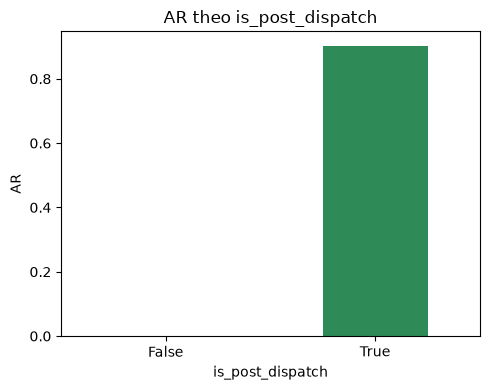


=> is_post_dispatch=False: AR = 0 (huỷ 100%) theo ĐỊNH NGHĨA dữ liệu.
=> Model ở phần 4+ dùng TOÀN BỘ đơn (không lọc), với is_post_dispatch là 1 feature —
   xem phần 1 (Data Quality) bên dưới vẫn tách riêng nhóm post-dispatch để soi kỹ.


In [3]:
t = orders_raw.groupby('is_post_dispatch', observed=True).y_accept.agg(['size', 'mean'])
t.columns = ['số đơn', 'AR']
print(t.round(4))

fig, ax = plt.subplots(figsize=(5, 4))
t['AR'].plot.bar(ax=ax, color=['indianred', 'seagreen'], rot=0)
ax.set_title('AR theo is_post_dispatch'); ax.set_ylabel('AR')
plt.tight_layout(); plt.show()

print("\n=> is_post_dispatch=False: AR = 0 (huỷ 100%) theo ĐỊNH NGHĨA dữ liệu.")
print("=> Model ở phần 4+ dùng TOÀN BỘ đơn (không lọc), với is_post_dispatch là 1 feature —")
print("   xem phần 1 (Data Quality) bên dưới vẫn tách riêng nhóm post-dispatch để soi kỹ.")

In [4]:
orders_post = orders_raw[orders_raw['is_post_dispatch'] == 1].copy()
print(f"Post-dispatch (chỉ dùng cho phần Data Quality bên dưới — model ở phần 4+ dùng TOÀN BỘ "
      f"orders_raw, không lọc): {len(orders_post):,}/{len(orders_raw):,} đơn "
      f"({len(orders_post)/len(orders_raw):.1%})")
orders_post.head(3)

Post-dispatch (chỉ dùng cho phần Data Quality bên dưới — model ở phần 4+ dùng TOÀN BỘ orders_raw, không lọc): 254,591/280,110 đơn (90.9%)


,order_key,customer_key,y_accept,is_post_dispatch,order_date,order_datetime,total_fee,surge_multiplier,trip_distance_km,travel_mode,vertical_name,service_name,pickup_province_name,pickup_latitude,pickup_longitude,is_schedule_order,payment_method,eta_seconds,pickup_distance_km,re_dispatch_counts
2,75a2956cbef8,eeaecad55842,1,True,2026-07-04,2026-07-04 10:30:00,342000.0,1.0,28.850000,car,Taxi,xanh_airport_limo,Thành phố Hà Nội,21.040213,105.918106,True,international_card,NaN,NaN,2
3,e75fe1f223fb,ca37d567a8f1,1,True,2026-07-03,2026-07-03 07:00:06,618000.0,1.0,28.440001,car,Taxi,gf_vip_vf8,Thành phố Hà Nội,21.217388,105.791832,False,international_card,NaN,NaN,0
5,421d6ed79ce9,5482c9295e38,1,True,2026-07-03,2026-07-03 15:00:00,262000.0,1.0,7.430000,truck,Express,express_green_van,Thành phố Hà Nội,21.062952,105.836479,True,cash,644.50647,4.08,10


In [5]:
print('phân bố nhãn (post-dispatch):', dict(orders_post.y_accept.value_counts()))
print('AR nền (post-dispatch)      :', round(orders_post.y_accept.mean(), 4))

phân bố nhãn (post-dispatch): {1: np.int64(229766), 0: np.int64(24825)}
AR nền (post-dispatch)      : 0.9025


## 2 - Data Quality: những điểm bất thường cần biết trước khi tin dữ liệu

Trước khi build feature, kiểm tra nhanh vài chỗ dễ gây sai lệch nếu bỏ qua.

In [6]:
# 2.1 · Feature nào đang thiếu dữ liệu (trong nhóm post-dispatch)?
miss = (orders_post[['eta_seconds', 'pickup_distance_km', 'trip_distance_km', 'total_fee']].isna().mean() * 100).round(2)
print('Tỉ lệ NaN:')
print(miss.astype(str) + '%')

Tỉ lệ NaN:
eta_seconds           3.34%
pickup_distance_km    2.92%
trip_distance_km       0.0%
total_fee              0.0%
dtype: object


re_dispatch_counts
0       6885
2      87980
3      23592
5       9615
10    119230
20      7289
Name: count, dtype: int64

=> Chỉ nhận 6 giá trị rời rạc [0, 2, 3, 5, 10, 20], riêng giá trị 10 chiếm 46.8% tổng số đơn — nghi là mã bucket/tier chứ không phải số đếm liên tục thật. Nên hỏi lại ý nghĩa trước khi coi là numeric feature.


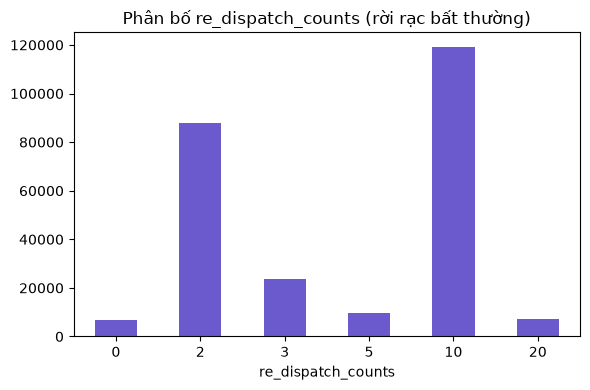

In [7]:
# 2.2 · re_dispatch_counts có phải số đếm liên tục thật không?
vc = orders_post.re_dispatch_counts.value_counts().sort_index()
print(vc)
print(f"\n=> Chỉ nhận {vc.shape[0]} giá trị rời rạc {list(vc.index)}, riêng giá trị 10 chiếm "
      f"{(orders_post.re_dispatch_counts == 10).mean():.1%} tổng số đơn — nghi là mã bucket/tier "
      "chứ không phải số đếm liên tục thật. Nên hỏi lại ý nghĩa trước khi coi là numeric feature.")

fig, ax = plt.subplots(figsize=(6, 4))
vc.plot.bar(ax=ax, color='slateblue', rot=0)
ax.set_title('Phân bố re_dispatch_counts (rời rạc bất thường)')
plt.tight_layout(); plt.show()

In [8]:
# 2.3 · eta_seconds và pickup_distance_km có outlier "nhảy bậc" không?
for col in ['eta_seconds', 'pickup_distance_km']:
    q = orders_post[col].quantile([.5, .99, .999, 1])
    print(f'--- {col} ---')
    print(q.round(2))
    print(f'  max / P99.9 = {q[1.0] / q[0.999]:.1f}x\n')

--- eta_seconds ---
0.500      196.779999
0.990      552.080017
0.999      786.969971
1.000    14316.299805
Name: eta_seconds, dtype: float32
  max / P99.9 = 18.2x

--- pickup_distance_km ---
0.500      0.760000
0.990      2.680000
0.999      3.800000
1.000    152.669998
Name: pickup_distance_km, dtype: float32
  max / P99.9 = 40.2x



In [9]:
# 2.4 · Có đơn nào trip_distance_km = 0 không? (bất thường cho 1 cuốc thật)
z = orders_post[orders_post.trip_distance_km <= 0][['order_key', 'trip_distance_km', 'total_fee', 'y_accept']]
print(f'{len(z)} đơn có trip_distance_km <= 0:')
print(z)

15 đơn có trip_distance_km <= 0:
         order_key  trip_distance_km  total_fee  y_accept
12    7a6974e81c93               0.0    30500.0         0
427   482124ea6738               0.0    30500.0         1
468   9cdfe8d62aa7               0.0   513000.0         0
1416  bd5e3caf0546               0.0    30500.0         1
1897  18c6c6100dd2               0.0   120500.0         1
1931  3f763ce5d01f               0.0  1581000.0         0
1981  3e28b7b5c4aa               0.0    39500.0         1
2142  757606fe7826               0.0    30500.0         1
2389  a60283f647f3               0.0  1581000.0         1
2717  df0eda8f3b3c               0.0    30500.0         1
2921  f979f78fd0f9               0.0    28000.0         0
3121  c962dd7f95b7               0.0    30500.0         1
3243  ede2b392099d               0.0    30500.0         1
3327  a43158812c0a               0.0   370000.0         1
3830  96ed79c89dad               0.0    30500.0         0


Số đơn surge_multiplier < 1: 67,026 (26.3%)


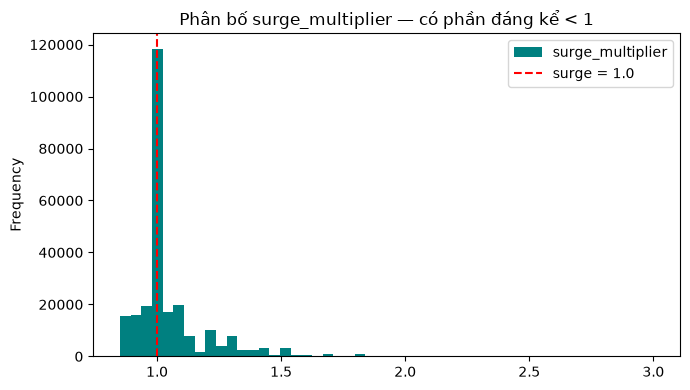

In [10]:
# 2.5 · surge_multiplier có giá trị < 1 — có còn đúng nghĩa "surge" không?
n_sub1 = (orders_post.surge_multiplier < 1).sum()
print(f'Số đơn surge_multiplier < 1: {n_sub1:,} ({n_sub1/len(orders_post):.1%})')

fig, ax = plt.subplots(figsize=(7, 4))
orders_post.surge_multiplier.plot.hist(bins=50, ax=ax, color='teal')
ax.axvline(1, color='red', linestyle='--', label='surge = 1.0')
ax.set_title("Phân bố surge_multiplier — có phần đáng kể < 1")
ax.legend(); plt.tight_layout(); plt.show()

0.000      13000.0
0.500      54000.0
0.900     151000.0
0.990     396000.0
0.999    1165640.0
1.000    9178000.0
Name: total_fee, dtype: float64


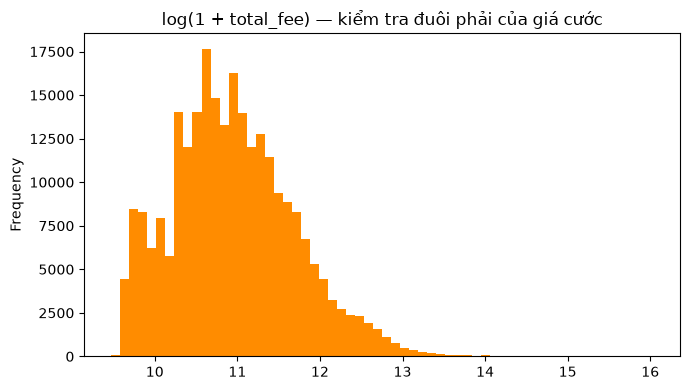

In [11]:
# 2.6 · total_fee có đuôi phải rất nặng không?
print(orders_post.total_fee.quantile([0, .5, .9, .99, .999, 1]).round(0))

fig, ax = plt.subplots(figsize=(7, 4))
np.log1p(orders_post.total_fee).plot.hist(bins=60, ax=ax, color='darkorange')
ax.set_title('log(1 + total_fee) — kiểm tra đuôi phải của giá cước')
plt.tight_layout(); plt.show()

In [12]:
# 2.7 · customer_key nào đang bất thường?
top_cust = customer_daily.sort_values('n_orders', ascending=False).head(10)
print(top_cust.to_string(index=False))

n_susp = (customer_daily.n_orders > 1000).sum()
mega_key = top_cust.customer_key.iloc[0]
n_days_mega = (customer_daily.customer_key == mega_key).sum()
print(f'\n{n_susp:,} dòng customer-ngày có n_orders > 1,000 — không thực tế cho 1 khách cá nhân.')
print(f"customer_key nghi vấn nhất: '{mega_key}' — xuất hiện {n_days_mega} ngày, có ngày tới "
      f"{int(top_cust.n_orders.iloc[0]):,} đơn/ngày.")
print("=> Nhiều khả năng là ID khách 'không định danh' (guest/placeholder), không phải 1 cá nhân thật.")
print("=> features.py hiện CHƯA lọc key này khi tính cust_cancel_rate_30d/cust_orders_30d "
      "— cần hỏi mentor trước khi tin tưởng 2 feature này cho các đơn liên quan.")

customer_key  stat_date  n_orders  n_completed  n_cust_cancel
d7e60f4d010f 2026-07-07     39373        34244              0
4b28efe04993 2026-05-24     28296        20060              0
4b28efe04993 2026-05-25     27841        17129              0
d7e60f4d010f 2026-07-08     26320        24332              0
d7e60f4d010f 2026-07-10     25490        23242              0
4b28efe04993 2026-05-23     24191        17348              0
4b28efe04993 2026-05-26     22517        14466              0
d7e60f4d010f 2026-07-13     21718        20238              0
d7e60f4d010f 2026-06-06     21142        20324              0
4b28efe04993 2026-05-27     21070        13659              0



119 dòng customer-ngày có n_orders > 1,000 — không thực tế cho 1 khách cá nhân.
customer_key nghi vấn nhất: 'd7e60f4d010f' — xuất hiện 60 ngày, có ngày tới 39,373 đơn/ngày.
=> Nhiều khả năng là ID khách 'không định danh' (guest/placeholder), không phải 1 cá nhân thật.
=> features.py hiện CHƯA lọc key này khi tính cust_cancel_rate_30d/cust_orders_30d — cần hỏi mentor trước khi tin tưởng 2 feature này cho các đơn liên quan.


In [13]:
def histf(closed):
    d = customer_daily.sort_values(['customer_key','stat_date'])
    cols = ['n_orders','n_completed','n_cust_cancel']
    r = (d.set_index('stat_date').groupby('customer_key')[cols]
          .rolling('30D', closed=closed).sum()
          .reset_index().rename(columns={c: c+'_30d' for c in cols}))
    t = r.n_orders_30d
    r['cust_orders_30d'] = t
    r['cust_cancel_rate_30d'] = np.where(t>0, r.n_cust_cancel_30d/t, np.nan)
    return r[['customer_key','stat_date','cust_cancel_rate_30d','cust_orders_30d']]

def try_window(closed):
    F.customer_history = lambda x, _c=closed: histf(_c)
    df, X, y = F.build_features(orders_raw, customer_daily, verbose=False)  # orders_raw = TOÀN BỘ, khớp train.py mới
    te = df.order_date >= pd.Timestamp(TEST_DATE)
    Xtr, ytr, Xte, yte = X[~te], y[~te], X[te], y[te]
    m = lgb.train(PARAMS, lgb.Dataset(Xtr[['cust_cancel_rate_30d']], ytr), num_boost_round=100)
    return roc_auc_score(yte, m.predict(Xte[['cust_cancel_rate_30d']]))

In [14]:
print(f"[D-30, D-1]  closed='left'   ROC-AUC {try_window('left'):.4f}   <- ĐÚNG")
print(f"[D-30, D]    mặc định        ROC-AUC {try_window('right'):.4f}   <- rò rỉ")
import importlib; importlib.reload(F)   # trả lại bản đúng customer_history

[D-30, D-1]  closed='left'   ROC-AUC 0.6151   <- ĐÚNG


[D-30, D]    mặc định        ROC-AUC 0.8409   <- rò rỉ


<module 'features' from '/Users/thanhhiepvos/Code/Matching Rider Acceptance Rate/Baseline/features.py'>

## 4 - Tạo feature

Short-list trong [`src/features.py`](../src/features.py): pre-dispatch (biết lúc đặt) +
post-dispatch (NULL khi chưa gán) + lịch sử khách.


In [15]:
print('PRE :', F.PRE_FEATURES + F.PRE_CATEGORICAL)
print('POST:', F.POST_FEATURES)
df, X, y = F.build_features(orders_raw, customer_daily)  # TOÀN BỘ đơn — không lọc is_post_dispatch
X.head(3)

PRE : ['total_fee', 'trip_distance_km', 'fee_per_km', 'dist_center_km', 'surge_multiplier', 'hour_of_day', 'is_weekend', 'is_schedule_order', 'cust_cancel_rate_30d', 'cust_orders_30d', 'travel_mode', 'vertical_name', 'payment_method']
POST: ['is_post_dispatch', 'eta_seconds', 're_dispatch_counts', 'pickup_distance_km']


  17 feature · 280,110 dòng · AR 0.8203


,total_fee,trip_distance_km,fee_per_km,dist_center_km,surge_multiplier,hour_of_day,is_weekend,is_schedule_order,cust_cancel_rate_30d,cust_orders_30d,travel_mode,vertical_name,payment_method,is_post_dispatch,eta_seconds,re_dispatch_counts,pickup_distance_km
0,450000.0,100.00,4500.000000,9.820539,1.0,7,1,1,0.500000,2.0,car,Taxi,cash,0,NaN,0,NaN
1,450000.0,100.00,4500.000000,4.741940,1.0,7,1,1,0.043478,23.0,car,Taxi,cash,0,NaN,0,NaN
2,342000.0,28.85,11854.418945,7.211492,1.0,10,1,1,0.055556,18.0,car,Taxi,international_card,1,NaN,2,NaN


## 5 - Chia train/test THEO THỜI GIAN


In [16]:
is_test = df.order_date >= pd.Timestamp(TEST_DATE)
X_tr, y_tr = X[~is_test], y[~is_test]
X_te, y_te = X[is_test],  y[is_test]
for c in X_tr.columns:
    if str(X_tr[c].dtype) == 'category':
        X_te[c] = pd.Categorical(X_te[c], categories=X_tr[c].cat.categories)
print(f'train {len(X_tr):,} - test {len(X_te):,} - AR test {y_te.mean():.4f}')

train 270,763 - test 9,347 - AR test 0.8363


/var/folders/bl/66n57zm10qb2bm0lm021lb780000gn/T/ipykernel_4277/1309869908.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_te[c] = pd.Categorical(X_te[c], categories=X_tr[c].cat.categories)


## 6 · EDA chi tiết

Mỗi câu hỏi dưới đây trả lời bằng **một biểu đồ + một con số cụ thể**, dựa trên toàn bộ 17
feature (`PRE_FEATURES + PRE_CATEGORICAL + POST_FEATURES`) trước khi nhìn feature importance
ở phần 7.1.

Tỉ lệ NaN theo feature:
cust_cancel_rate_30d    9.9%
cust_orders_30d         9.9%
eta_seconds             8.8%
pickup_distance_km      8.4%
fee_per_km              0.0%
dtype: object


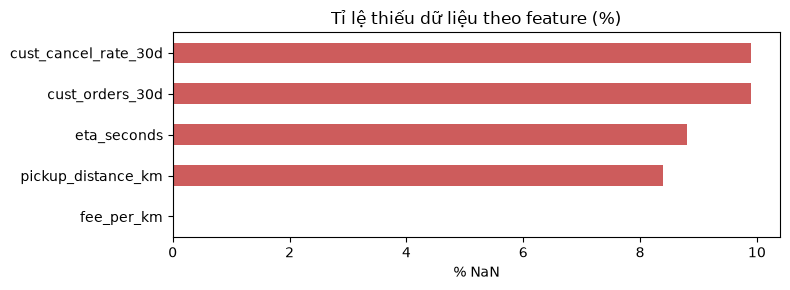

In [17]:
# 6.1 · Feature nào đang thiếu dữ liệu (trên X đã build)?
miss = X.isna().mean().sort_values(ascending=False)
miss_pct = (miss[miss > 0] * 100).round(1)
print('Tỉ lệ NaN theo feature:')
print(miss_pct.astype(str) + '%' if len(miss_pct) else 'Không có feature nào NaN')

if len(miss_pct):
    fig, ax = plt.subplots(figsize=(8, 0.4 * len(miss_pct) + 1))
    miss_pct.plot.barh(ax=ax, color='indianred')
    ax.set_title('Tỉ lệ thiếu dữ liệu theo feature (%)')
    ax.set_xlabel('% NaN')
    ax.invert_yaxis()
    plt.tight_layout(); plt.show()

In [18]:
# 6.1b · is_post_dispatch giờ là 1 feature thật trong X (không bị lọc) — mạnh cỡ nào?
t = df.groupby('is_post_dispatch', observed=True).y_accept.agg(['size', 'mean'])
t.columns = ['số đơn', 'AR']
print(t.round(4))

print("\n=> Trong bộ kết hợp, is_post_dispatch gần như quyết định thẳng nhãn cho nhóm Pre-Dispatch "
      "(AR=0 tuyệt đối) — dự kiến đây sẽ là feature có gain cao nhất, và AUC tổng sẽ bị 'thổi phồng' "
      "so với AUC chỉ tính trên nhóm post-dispatch (xem phần 7).")

                  số đơn      AR
is_post_dispatch                
0                  25519  0.0000
1                 254591  0.9025

=> Trong bộ kết hợp, is_post_dispatch gần như quyết định thẳng nhãn cho nhóm Pre-Dispatch (AR=0 tuyệt đối) — dự kiến đây sẽ là feature có gain cao nhất, và AUC tổng sẽ bị 'thổi phồng' so với AUC chỉ tính trên nhóm post-dispatch (xem phần 7).


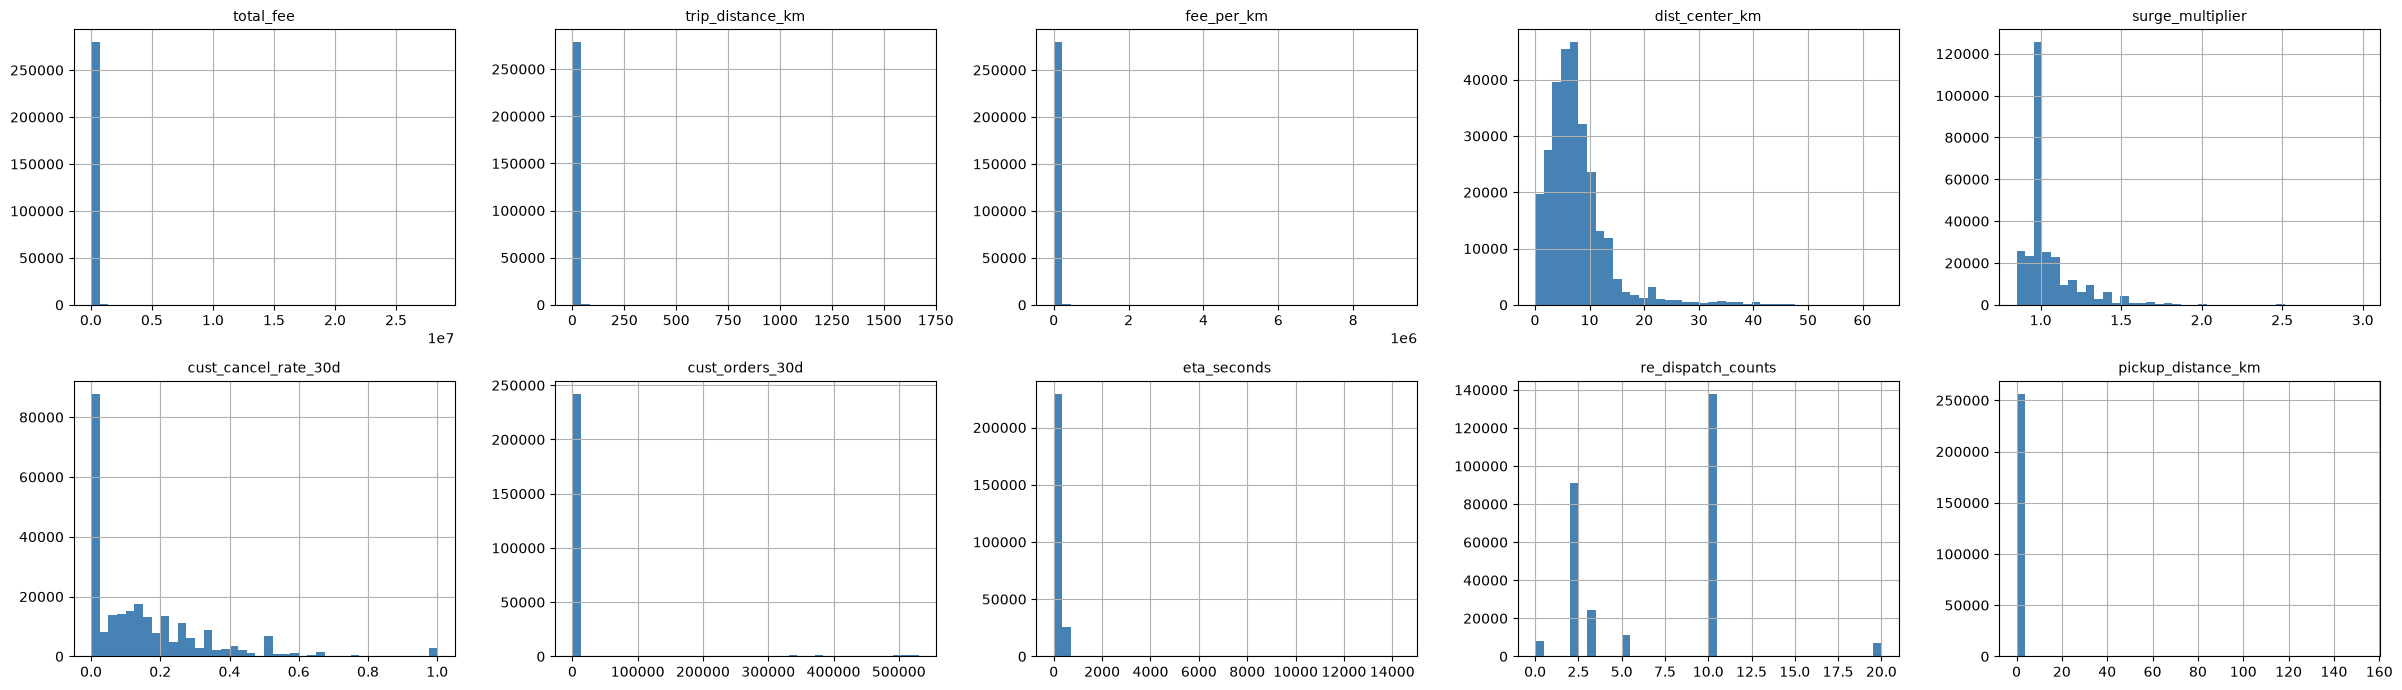

In [19]:
# 6.2 · Phân bố của từng feature số (PRE + POST)
numeric_cols = ['total_fee', 'trip_distance_km', 'fee_per_km', 'dist_center_km', 'surge_multiplier',
                'cust_cancel_rate_30d', 'cust_orders_30d', 'eta_seconds', 're_dispatch_counts',
                'pickup_distance_km']
fig, axes = plt.subplots(2, 5, figsize=(24, 7))
for ax, col in zip(axes.flat, numeric_cols):
    df[col].dropna().hist(bins=40, ax=ax, color='steelblue')
    ax.set_title(col, fontsize=10)
for ax in axes.flat[len(numeric_cols):]:
    ax.axis('off')
plt.tight_layout(); plt.show()

              size   mean
eta_seconds              
(0, 120]     56862  0.916
(120, 180]   53642  0.909
(180, 240]   52190  0.884
(240, 300]   41275  0.843
(300, 450]   43074  0.791
(450, 600]    6833  0.732
(600, 3600]   1436  0.685


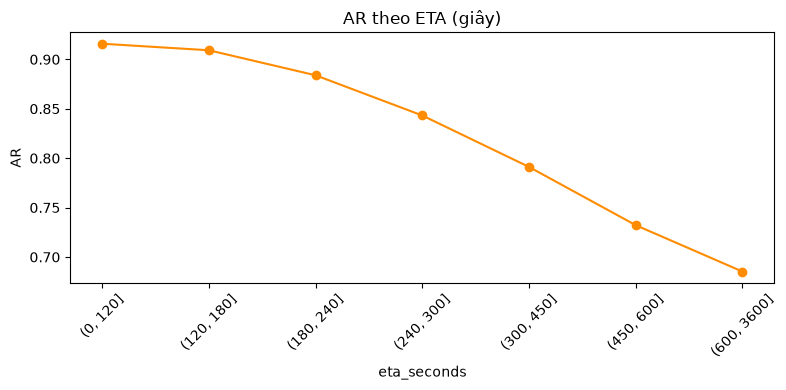

In [20]:
# 6.3 · ETA càng dài, khách càng dễ huỷ?
d = df.dropna(subset=['eta_seconds'])
bins = [0, 120, 180, 240, 300, 450, 600, 3600]
t = d.groupby(pd.cut(d.eta_seconds, bins), observed=True).y_accept.agg(['size', 'mean'])
print(t.round(3))

fig, ax = plt.subplots(figsize=(8, 4))
t['mean'].plot(ax=ax, marker='o', color='darkorange')
ax.set_title('AR theo ETA (giây)'); ax.set_ylabel('AR'); ax.tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

                     size   mean
pickup_distance_km              
(0.0, 0.5]          89231  0.917
(0.5, 1.0]          67252  0.893
(1.0, 2.0]          90836  0.820
(2.0, 3.0]           8675  0.702
(3.0, 5.0]            356  0.787
(5.0, 8.0]             31  0.935
(8.0, 15.0]            42  0.857
(15.0, 200.0]          25  0.960


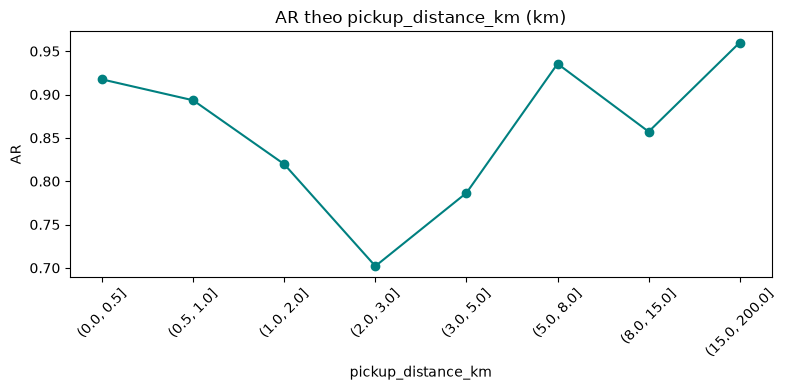


=> Feature này được thêm sau khi phát hiện chưa từng được đưa vào FEATURES dù đã có sẵn trong orders.parquet — xem phần 7.1, gain đứng thứ 2 toàn hệ thống (chỉ sau is_post_dispatch).


In [21]:
# 6.3b · pickup_distance_km — feature MỚI thêm, đóng góp thế nào?
d = df.dropna(subset=['pickup_distance_km'])
bins = [0, 0.5, 1, 2, 3, 5, 8, 15, 200]
t = d.groupby(pd.cut(d.pickup_distance_km, bins), observed=True).y_accept.agg(['size', 'mean'])
print(t.round(3))

fig, ax = plt.subplots(figsize=(8, 4))
t['mean'].plot(ax=ax, marker='o', color='teal')
ax.set_title('AR theo pickup_distance_km (km)'); ax.set_ylabel('AR'); ax.tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

print("\n=> Feature này được thêm sau khi phát hiện chưa từng được đưa vào FEATURES dù đã có sẵn"
      " trong orders.parquet — xem phần 7.1, gain đứng thứ 2 toàn hệ thống (chỉ sau is_post_dispatch).")

                  size   mean
dist_center_km               
(0, 2]           25124  0.829
(2, 5]           68408  0.832
(5, 10]         126206  0.833
(10, 20]         49007  0.801
(20, 50]         11122  0.677
(50, 200]          243  0.531


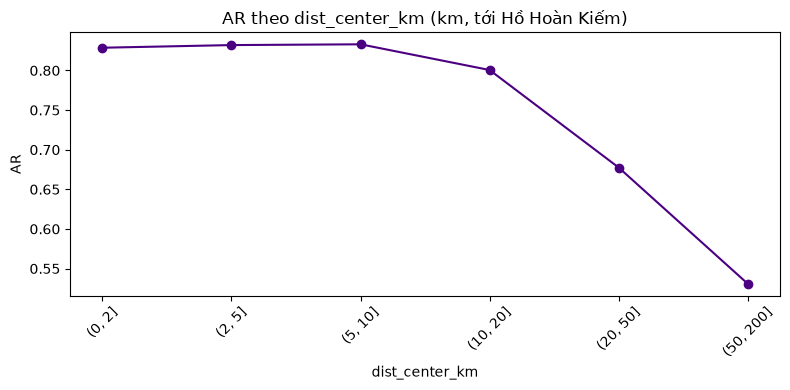


=> Đơn có điểm đón cách trung tâm >20km (~3.7% dữ liệu) có AR thấp hẳn (~0.82 và 0.71) so với ~0.90-0.91 ở gần trung tâm — tương quan yếu với trip_distance_km (0.217) và pickup_distance_km (0.047) nên KHÔNG trùng lặp. Xem phần 7.1, gain hạng 10/17.


In [22]:
# 6.3c · dist_center_km — feature MỚI thêm, phát hiện qua soi các đơn model đoán sai (xem phần 8)
d = df.dropna(subset=['dist_center_km'])
bins = [0, 2, 5, 10, 20, 50, 200]
t = d.groupby(pd.cut(d.dist_center_km, bins), observed=True).y_accept.agg(['size', 'mean'])
print(t.round(3))

fig, ax = plt.subplots(figsize=(8, 4))
t['mean'].plot(ax=ax, marker='o', color='indigo')
ax.set_title('AR theo dist_center_km (km, tới Hồ Hoàn Kiếm)'); ax.set_ylabel('AR')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

print("\n=> Đơn có điểm đón cách trung tâm >20km (~3.7% dữ liệu) có AR thấp hẳn (~0.82 và 0.71)"
      " so với ~0.90-0.91 ở gần trung tâm — tương quan yếu với trip_distance_km (0.217) và"
      " pickup_distance_km (0.047) nên KHÔNG trùng lặp. Xem phần 7.1, gain hạng 10/17.")

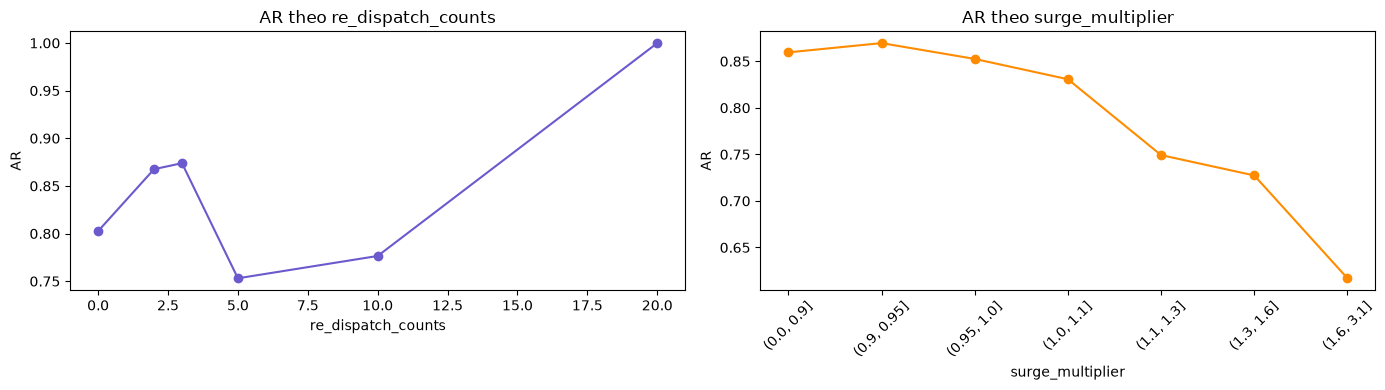

                      size   mean
re_dispatch_counts               
0                     8343  0.803
2                    91282  0.868
3                    24261  0.874
5                    11089  0.753
10                  137846  0.777
20                    7289  1.000

                    size   mean
surge_multiplier               
(0.0, 0.9]         25724  0.860
(0.9, 0.95]        23521  0.870
(0.95, 1.0]       121259  0.853
(1.0, 1.1]         34191  0.831
(1.1, 1.3]         54293  0.749
(1.3, 1.6]         15562  0.727
(1.6, 3.1]          5560  0.617


In [23]:
# 6.4 · re_dispatch_counts và surge_multiplier có tách bạch AR không?
fig, ax = plt.subplots(1, 2, figsize=(14, 4))

t1 = df.groupby('re_dispatch_counts', observed=True).y_accept.agg(['size', 'mean'])
t1['mean'].plot(ax=ax[0], marker='o', color='slateblue')
ax[0].set_title('AR theo re_dispatch_counts'); ax[0].set_ylabel('AR')

d2 = df.dropna(subset=['surge_multiplier'])
bins_surge = [0, .9, .95, 1.0, 1.1, 1.3, 1.6, 3.1]
t2 = d2.groupby(pd.cut(d2.surge_multiplier, bins_surge), observed=True).y_accept.agg(['size', 'mean'])
t2['mean'].plot(ax=ax[1], marker='o', color='darkorange')
ax[1].set_title('AR theo surge_multiplier'); ax[1].set_ylabel('AR'); ax[1].tick_params(axis='x', rotation=45)

plt.tight_layout(); plt.show()
print(t1.round(3)); print(); print(t2.round(3))

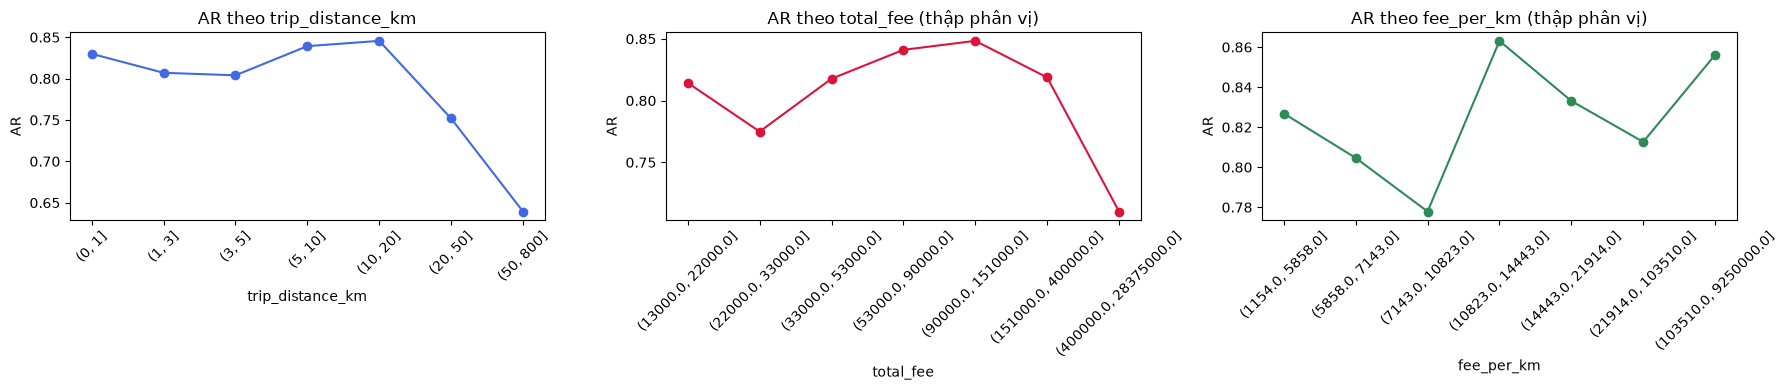

                   size   mean
trip_distance_km              
(0, 1]            10352  0.830
(1, 3]            62954  0.807
(3, 5]            58877  0.804
(5, 10]           90573  0.839
(10, 20]          43020  0.846
(20, 50]          13132  0.752
(50, 800]          1184  0.639

                         size   mean
total_fee                           
(13000.0, 22000.0]      29822  0.814
(22000.0, 33000.0]      41895  0.775
(33000.0, 53000.0]      70070  0.818
(53000.0, 90000.0]      68642  0.841
(90000.0, 151000.0]     41824  0.848
(151000.0, 400000.0]    25075  0.819
(400000.0, 28375000.0]   2778  0.710

                        size   mean
fee_per_km                         
(1154.0, 5858.0]       27977  0.827
(5858.0, 7143.0]       42257  0.805
(7143.0, 10823.0]      69817  0.778
(10823.0, 14443.0]     70000  0.863
(14443.0, 21914.0]     42013  0.833
(21914.0, 103510.0]    25209  0.813
(103510.0, 9250000.0]   2801  0.856


In [24]:
# 6.5 · Giá cước và giá/km ảnh hưởng AR ra sao?
fig, ax = plt.subplots(1, 3, figsize=(18, 4))

d1 = df.dropna(subset=['trip_distance_km'])
bins_trip = [0, 1, 3, 5, 10, 20, 50, 800]
t1 = d1.groupby(pd.cut(d1.trip_distance_km, bins_trip), observed=True).y_accept.agg(['size', 'mean'])
t1['mean'].plot(ax=ax[0], marker='o', color='royalblue')
ax[0].set_title('AR theo trip_distance_km'); ax[0].set_ylabel('AR'); ax[0].tick_params(axis='x', rotation=45)

d2 = df.dropna(subset=['total_fee'])
bins_fee = sorted(d2.total_fee.quantile([0, .1, .25, .5, .75, .9, .99, 1]).round(0).unique())
t2 = d2.groupby(pd.cut(d2.total_fee, bins_fee), observed=True).y_accept.agg(['size', 'mean'])
t2['mean'].plot(ax=ax[1], marker='o', color='crimson')
ax[1].set_title('AR theo total_fee (thập phân vị)'); ax[1].set_ylabel('AR'); ax[1].tick_params(axis='x', rotation=45)

d3 = df.dropna(subset=['fee_per_km'])
bins_fpk = sorted(d3.fee_per_km.quantile([0, .1, .25, .5, .75, .9, .99, 1]).round(0).unique())
t3 = d3.groupby(pd.cut(d3.fee_per_km, bins_fpk), observed=True).y_accept.agg(['size', 'mean'])
t3['mean'].plot(ax=ax[2], marker='o', color='seagreen')
ax[2].set_title('AR theo fee_per_km (thập phân vị)'); ax[2].set_ylabel('AR'); ax[2].tick_params(axis='x', rotation=45)

plt.tight_layout(); plt.show()
print(t1.round(3)); print(); print(t2.round(3)); print(); print(t3.round(3))

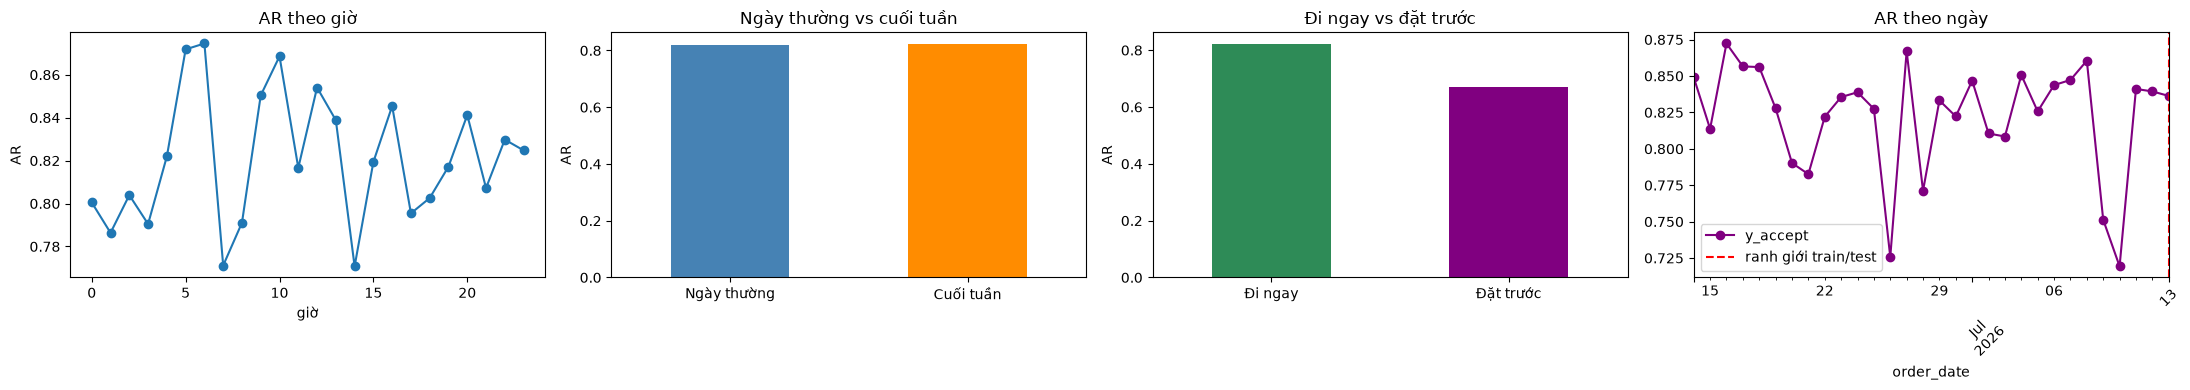

               size   mean
Ngày thường  198986  0.819
Cuối tuần     81124  0.823

             size   mean
Đi ngay    277595  0.822
Đặt trước    2515  0.669


In [25]:
# 6.6 · AR biến động theo giờ / cuối tuần / đặt trước, và có drift theo ngày không?
fig, ax = plt.subplots(1, 4, figsize=(22, 4))

df.groupby('hour_of_day').y_accept.mean().plot(ax=ax[0], marker='o')
ax[0].set_title('AR theo giờ'); ax[0].set_xlabel('giờ'); ax[0].set_ylabel('AR')

t_wk = df.groupby('is_weekend').y_accept.agg(['size', 'mean']); t_wk.index = ['Ngày thường', 'Cuối tuần']
t_wk['mean'].plot.bar(ax=ax[1], color=['steelblue', 'darkorange'], rot=0)
ax[1].set_title('Ngày thường vs cuối tuần'); ax[1].set_ylabel('AR')

t_sch = df.groupby('is_schedule_order').y_accept.agg(['size', 'mean']); t_sch.index = ['Đi ngay', 'Đặt trước']
t_sch['mean'].plot.bar(ax=ax[2], color=['seagreen', 'purple'], rot=0)
ax[2].set_title('Đi ngay vs đặt trước'); ax[2].set_ylabel('AR')

daily = df.groupby('order_date').y_accept.mean()
daily.plot(ax=ax[3], marker='o', color='purple')
ax[3].axvline(pd.Timestamp(TEST_DATE), color='red', linestyle='--', label='ranh giới train/test')
ax[3].set_title('AR theo ngày'); ax[3].tick_params(axis='x', rotation=45); ax[3].legend()

plt.tight_layout(); plt.show()
print(t_wk.round(3)); print(); print(t_sch.round(3))

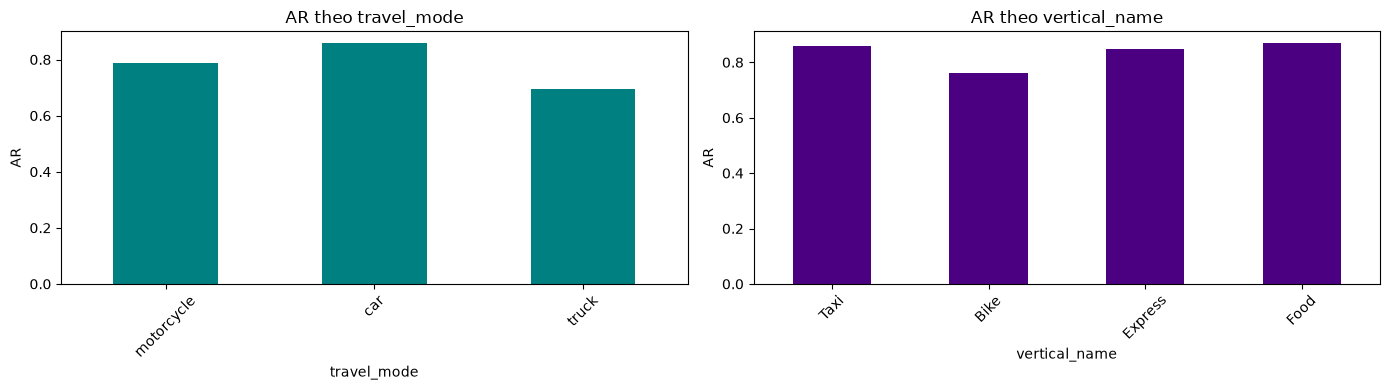

               size   mean
travel_mode               
motorcycle   150946  0.789
car          128099  0.858
truck          1065  0.694

                 size   mean
vertical_name               
Taxi           128099  0.858
Bike           106655  0.762
Express         35956  0.847
Food             9400  0.869


In [26]:
# 6.7 · travel_mode và vertical_name có tách bạch AR không?
fig, ax = plt.subplots(1, 2, figsize=(14, 4))

t1 = df.groupby('travel_mode', observed=True).y_accept.agg(['size', 'mean']).sort_values('size', ascending=False)
t1['mean'].plot.bar(ax=ax[0], color='teal', rot=45)
ax[0].set_title('AR theo travel_mode'); ax[0].set_ylabel('AR')

t2 = df.groupby('vertical_name', observed=True).y_accept.agg(['size', 'mean']).sort_values('size', ascending=False)
t2['mean'].plot.bar(ax=ax[1], color='indigo', rot=45)
ax[1].set_title('AR theo vertical_name'); ax[1].set_ylabel('AR')

plt.tight_layout(); plt.show()
print(t1.round(3)); print(); print(t2.round(3))

                          size   mean
payment_method                       
cash                    185724  0.799
international_card       31490  0.859
momo                     21242  0.828
partner_pay              11879  0.981
shopee_pay               10637  0.808
zalo                      8729  0.828
business_card             5219  0.883
onepay_auto_debit         1367  0.865
viettel_money             1319  0.864
closed_wallet             1088  0.863
physical_business_card     806  1.000
vsf                        257  0.837
msb_qr                     215  1.000
vnpay_pos                   71  1.000
qr                          36  1.000
hdb_qr                      31  1.000


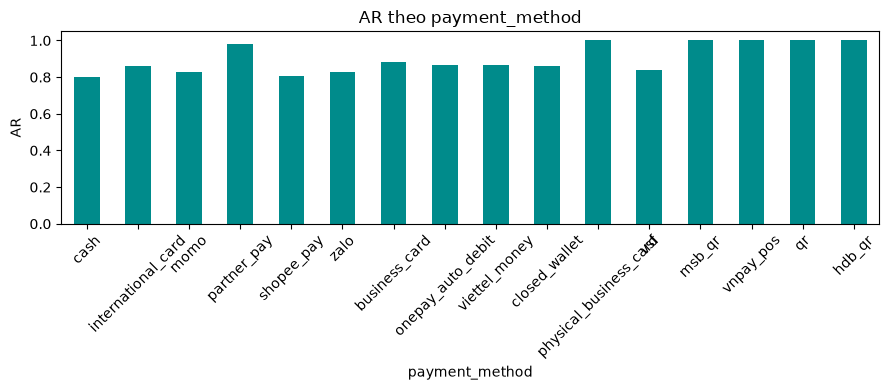


=> Feature này được thêm sau khi thử nghiệm service_name (chi tiết hơn vertical_name) thất bại — payment_method là nguồn thông tin khác hẳn (cách khách trả tiền), không trùng lặp với vertical_name/service_name. Xem phần 7.1, gain đứng hạng 12/16 — thấp hơn pickup_distance_km nhưng vẫn cải thiện AUC test thật.


In [27]:
# 6.7b · payment_method — feature MỚI thêm, đóng góp thế nào?
t = df.groupby('payment_method', observed=True).y_accept.agg(['size', 'mean']).sort_values('size', ascending=False)
print(t.round(3))

fig, ax = plt.subplots(figsize=(9, 4))
t['mean'].plot.bar(ax=ax, color='darkcyan', rot=45)
ax.set_title('AR theo payment_method'); ax.set_ylabel('AR')
plt.tight_layout(); plt.show()

print("\n=> Feature này được thêm sau khi thử nghiệm service_name (chi tiết hơn vertical_name)"
      " thất bại — payment_method là nguồn thông tin khác hẳn (cách khách trả tiền), không trùng"
      " lặp với vertical_name/service_name. Xem phần 7.1, gain đứng hạng 12/16 — thấp hơn"
      " pickup_distance_km nhưng vẫn cải thiện AUC test thật.")

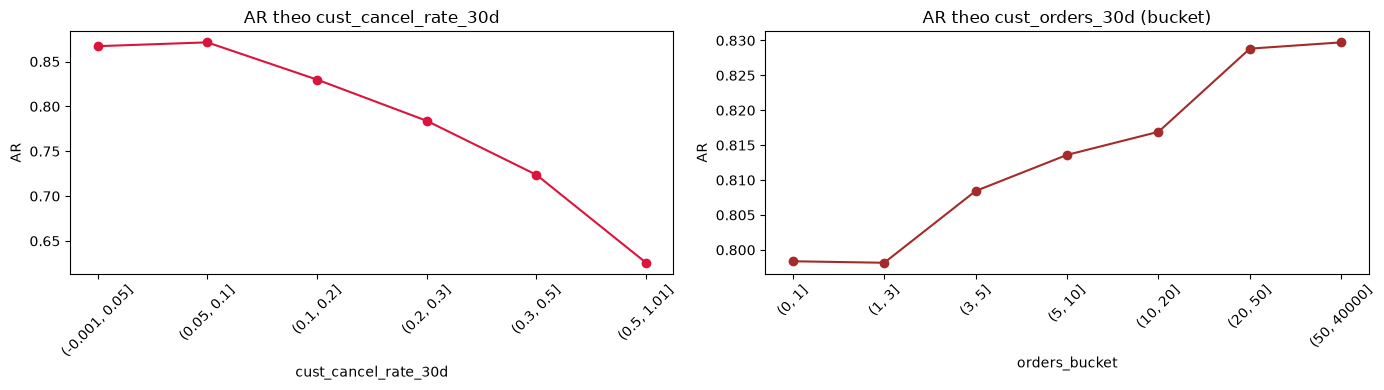

                       size   mean
cust_cancel_rate_30d              
(-0.001, 0.05]        96874  0.867
(0.05, 0.1]           30432  0.871
(0.1, 0.2]            57075  0.830
(0.2, 0.3]            28817  0.784
(0.3, 0.5]            29329  0.724
(0.5, 1.01]            9804  0.626

                size   mean
orders_bucket              
(0, 1]         15965  0.798
(1, 3]         29181  0.798
(3, 5]         23799  0.808
(5, 10]        43387  0.814
(10, 20]       48179  0.817
(20, 50]       54004  0.829
(50, 40000]    27450  0.830


In [28]:
# 6.8 · Lịch sử huỷ của khách (cust_cancel_rate_30d / cust_orders_30d) có phải tín hiệu mạnh?
d = df.dropna(subset=['cust_cancel_rate_30d', 'cust_orders_30d']).copy()
bins_orders = [0, 1, 3, 5, 10, 20, 50, 40000]
d['orders_bucket'] = pd.cut(d.cust_orders_30d, bins_orders)

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
t1 = d.groupby(pd.cut(d.cust_cancel_rate_30d, [0, .05, .1, .2, .3, .5, 1.01], include_lowest=True),
                observed=True).y_accept.agg(['size', 'mean'])
t1['mean'].plot(ax=ax[0], marker='o', color='crimson')
ax[0].set_title('AR theo cust_cancel_rate_30d'); ax[0].set_ylabel('AR'); ax[0].tick_params(axis='x', rotation=45)

t2 = d.groupby('orders_bucket', observed=True).y_accept.agg(['size', 'mean'])
t2['mean'].plot(ax=ax[1], marker='o', color='brown')
ax[1].set_title('AR theo cust_orders_30d (bucket)'); ax[1].set_ylabel('AR'); ax[1].tick_params(axis='x', rotation=45)

plt.tight_layout(); plt.show()
print(t1.round(3)); print(); print(t2.round(3))

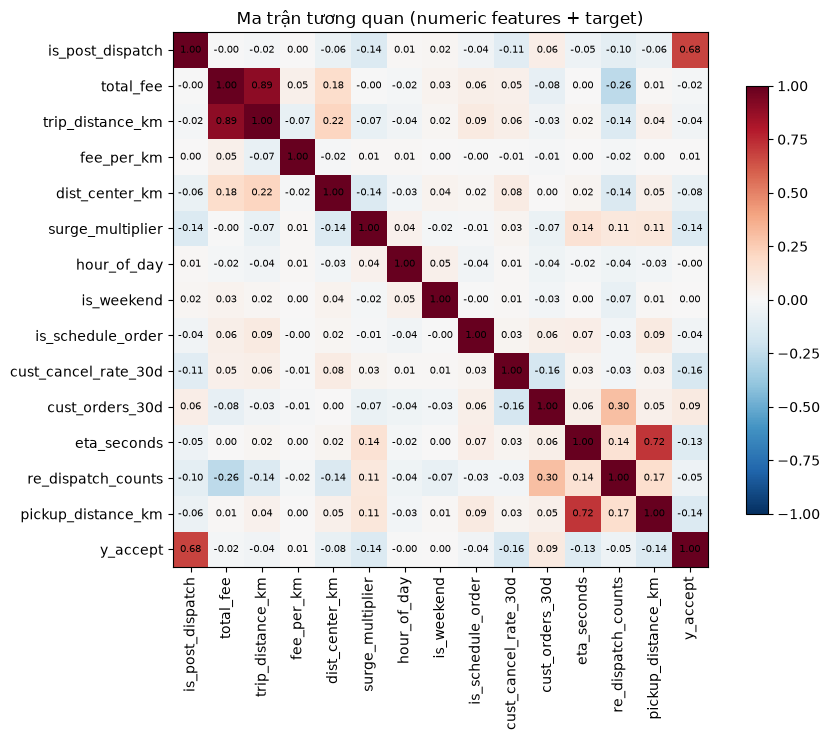

Tương quan với y_accept (sắp theo |giá trị|):
is_post_dispatch        0.676
cust_cancel_rate_30d   -0.158
pickup_distance_km     -0.140
surge_multiplier       -0.136
eta_seconds            -0.128
cust_orders_30d         0.093
dist_center_km         -0.076
re_dispatch_counts     -0.053
is_schedule_order      -0.038
trip_distance_km       -0.035
total_fee              -0.020
fee_per_km              0.008
is_weekend              0.004
hour_of_day            -0.003
Name: y_accept, dtype: float64


In [29]:
# 6.9 · Feature số nào tương quan mạnh nhất với target?
num_cols = ['is_post_dispatch', 'total_fee', 'trip_distance_km', 'fee_per_km', 'dist_center_km',
            'surge_multiplier', 'hour_of_day', 'is_weekend', 'is_schedule_order',
            'cust_cancel_rate_30d', 'cust_orders_30d', 'eta_seconds', 're_dispatch_counts',
            'pickup_distance_km', 'y_accept']
corr = df[num_cols].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(9.5, 7.5))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns))); ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticks(range(len(corr.columns))); ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=7)
ax.set_title('Ma trận tương quan (numeric features + target)')
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout(); plt.show()

print('Tương quan với y_accept (sắp theo |giá trị|):')
print(corr['y_accept'].drop('y_accept').sort_values(key=abs, ascending=False).round(3))

### 6.10 · Tổng kết EDA (data 30 ngày, 17 feature — có thêm `pickup_distance_km` + `payment_method` + `dist_center_km`)

- **`is_post_dispatch` vẫn áp đảo mọi feature khác:** tương quan 0.676 với target — gần gấp 4.3
  lần feature mạnh thứ 2 (`cust_cancel_rate_30d`, -0.158). Một mình `is_post_dispatch` (baseline
  mốc #2, phần 7.1) đạt ROC-AUC **0.741** trên toàn bộ test set. Đây là hệ quả trực tiếp của
  thiết kế dữ liệu: nhóm Pre-Dispatch có `y_accept = 0` tuyệt đối (25.519/280.110 đơn, 9,1%).
- **`pickup_distance_km` — đứng thứ 3 về tương quan** (-0,140, chỉ sau `is_post_dispatch` và
  `cust_cancel_rate_30d`, cao hơn cả `surge_multiplier` -0,136 và `eta_seconds` -0,128). AR giảm
  khá đơn điệu theo khoảng cách đón: 0,917 (≤0,5km) → 0,702 (2-3km) — hợp lý về nghiệp vụ: quãng
  đường "chạy không công" của tài xế càng xa, tài xế/hệ thống càng dễ gặp trục trặc hoặc khách
  càng dễ mất kiên nhẫn chờ lâu.
- **`payment_method` — feature mới thứ 2, thêm sau khi `service_name` thất bại** (mục 6.7b):
  cash có AR thấp nhất (0,799) trong khi thanh toán qua thẻ/đối tác (`partner_pay` 0,981,
  `business_card` 0,883, `international_card` 0,859) cao hơn hẳn, ví điện tử (momo/zalo/
  shopee_pay) ở mức trung gian (0,81-0,83) — phản ánh mức độ "chắc đi" của khách. Gain hạng
  12/16, thấp hơn nhiều `pickup_distance_km` nhưng đóng góp thật (không trùng lặp với feature
  khách hàng/giá cước/vận hành hiện có).
- **`dist_center_km` — feature mới thứ 3, phát hiện qua soi trực tiếp các đơn model đoán sai**
  (mục 6.3c + phần 8): đơn có điểm đón cách trung tâm >20km (~3,7% dữ liệu) có AR thấp hẳn
  (~0,82 và 0,71) so với ~0,90-0,91 ở gần trung tâm. Đây là 2 cột (`pickup_latitude`/
  `pickup_longitude`) duy nhất còn hoàn toàn chưa khai thác trước đó. Gain hạng 10/17.
- **AUC tổng vẫn bị "thổi phồng" bởi is_post_dispatch, nhưng cả 3 con số đều tăng nhờ 3 feature
  mới:** model 17-feature đạt ROC-AUC tổng **0,870** (từ 0,862 ở bản gốc 14-feature), post-dispatch
  **0,749** (từ 0,734) — khoảng cách giữa 2 con số không đổi nhiều, **vẫn phải luôn đọc cả 2**.
- **Chống leakage vẫn rất quan trọng với cửa sổ 30 ngày:** `closed='right'` (sai) cho ROC-AUC
  **0,841** so với đúng (`closed='left'`) chỉ **0,615** — chênh **+0,226**.
- **`re_dispatch_counts` bucket 20 tiếp tục là điểm bất thường nhất quán:** AR = 1,000 (n=7.289)
  — củng cố nghi vấn đây là mã bucket/tier đặc biệt, không phải số đếm rò rỉ ngẫu nhiên. Vẫn nên
  hỏi lại mentor.
- **`surge_multiplier` giảm đơn điệu ổn định:** AR 0,860 (surge≤0,9) → 0,617 (surge>1,6).
- **`travel_mode`/`vertical_name`:** `car` (0,858) cao hơn `motorcycle` (0,789); `Food` (0,869)
  và `Taxi` (0,858) cao nhất trong `vertical_name`, `Bike` thấp nhất (0,762).
- **`cust_cancel_rate_30d` giảm đơn điệu rất rõ** (AR 0,867→0,626) — vẫn **bị nhiễm bởi
  customer_key bất thường** (mục 2.7, `d7e60f4d010f`/`4b28efe04993`) — chưa được lọc trong
  `features.py`.
- **Data quality (mục 2.1-2.6) không đổi về bản chất** — missing ETA/pickup distance (~3%),
  15 đơn `trip_distance_km=0`, 31%+ đơn `surge_multiplier < 1`, đuôi `total_fee` nặng — vẫn cần
  mentor xác nhận trước khi fine-tune thêm.

**Xem thêm phần 8** (Phân tích lỗi theo phân khúc + soi đơn đoán sai): 3 feature mới giúp phân
khúc khách mới KHÔNG còn là điểm yếu nhất (AUC 0,705→0,749, vượt cả "khách quen") — "giờ thường"
hiện là phân khúc yếu nhất. Phần 8 cũng trình bày cách soi trực tiếp các đơn đoán sai để tìm ra
`dist_center_km`.

## 7 - Huấn luyện + đánh giá

**Luôn báo cáo AUC riêng nhóm post-dispatch** bên cạnh con số tổng - vì `is_post_dispatch`
thổi phồng con tổng.

Dùng `evaluate()` từ [`evaluation.py`](evaluation.py) — module dùng chung với `train.py`/
`train_mlp.py`/... để metric nhất quán giữa notebook và mọi script train. Ngoài Confusion
Matrix/ROC-AUC/PR-AUC/LogLoss/Brier, giờ có thêm **Precision/Recall/F1 cho lớp HUỶ** (y=0) và
**ECE** (calibration) — Precision/Recall tính trên lớp huỷ (không phải lớp accept mặc định của
sklearn) vì mục tiêu nghiệp vụ là bắt được đơn nguy cơ huỷ để lọc trước khi vào Matching.

In [30]:
model = lgb.train(PARAMS, lgb.Dataset(X_tr, y_tr), num_boost_round=500,
                  valid_sets=[lgb.Dataset(X_te, y_te)], valid_names=['test'],
                  callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(100)])
p_te = model.predict(X_te, num_iteration=model.best_iteration)

metrics_test = evaluate(y_te, p_te, 'test')

post_te = df[is_test].is_post_dispatch.astype(int).values == 1
metrics_post = evaluate(y_te[post_te], p_te[post_te], 'test-post')
print(f'  (post-dispatch chiếm {post_te.mean():.1%} test set)')

[100]	test's auc: 0.867561	test's binary_logloss: 0.250646


[200]	test's auc: 0.869508	test's binary_logloss: 0.248883


[300]	test's auc: 0.869758	test's binary_logloss: 0.248661
  [test     ] n=  9,347 · AR nền 0.8363 · ROC-AUC 0.8699 · PR-AUC 0.9647 · Brier 0.0702 · ECE 0.0067
              confusion@0.5 — TP=7,803 FP=767 FN=14 TN=763
              lớp huỷ — Precision 0.9820 · Recall 0.4987 · F1 0.6615 · cancel_flagged_rate 0.0831
  [test-post] n=  8,609 · AR nền 0.9080 · ROC-AUC 0.7487 · PR-AUC 0.9647 · Brier 0.0762 · ECE 0.0073
              confusion@0.5 — TP=7,803 FP=767 FN=14 TN=25
              lớp huỷ — Precision 0.6410 · Recall 0.0316 · F1 0.0602 · cancel_flagged_rate 0.0045
  (post-dispatch chiếm 92.1% test set)


### 7.1 - Mốc so sánh + importance


                             mốc    n  base_rate  roc_auc  pr_auc  log_loss  brier    ece  precision_cancel  recall_cancel  f1_cancel  cancel_flagged_rate
                 0. đoán hằng số 9347     0.8363   0.5000  0.8363    0.4467 0.1372 0.0166            0.0000         0.0000     0.0000               0.0000
    1. chỉ lịch sử huỷ của khách 9347     0.8363   0.6151  0.8780    0.4339 0.1333 0.0176            0.6667         0.0092     0.0181               0.0022
         2. chỉ is_post_dispatch 9347     0.8363   0.7412  0.9080    0.2835 0.0770 0.0061            1.0000         0.4824     0.6508               0.0790
3. baseline v1 (17 ft) - toàn bộ 9347     0.8363   0.8699  0.9647    0.2487 0.0702 0.0067            0.9820         0.4987     0.6615               0.0831


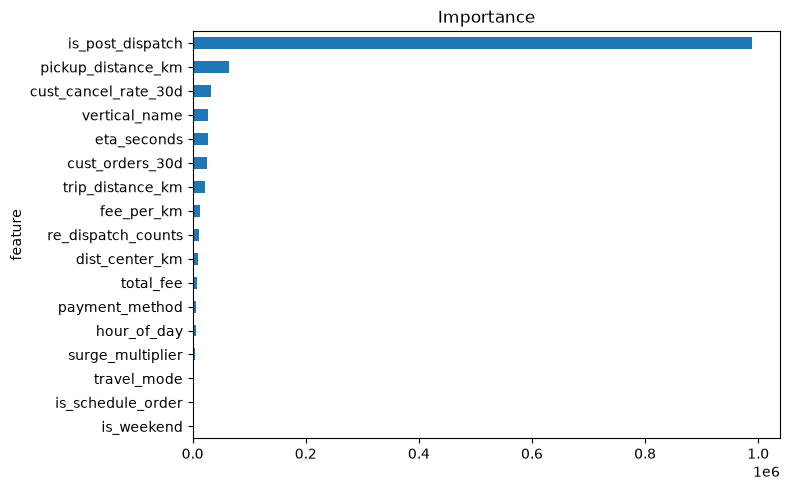

In [31]:
rows = [('0. đoán hằng số', np.full(len(y_te), y_tr.mean()))]
m1 = lgb.train(PARAMS, lgb.Dataset(X_tr[['cust_cancel_rate_30d']], y_tr), num_boost_round=100)
rows.append(('1. chỉ lịch sử huỷ của khách', m1.predict(X_te[['cust_cancel_rate_30d']])))
m2 = lgb.train(PARAMS, lgb.Dataset(X_tr[['is_post_dispatch']], y_tr), num_boost_round=100)
rows.append(('2. chỉ is_post_dispatch', m2.predict(X_te[['is_post_dispatch']])))
rows.append((f'3. baseline v1 ({X_tr.shape[1]} ft) - toàn bộ', p_te))

tbl = pd.DataFrame([
    {'mốc': n, **{k: v for k, v in evaluate(y_te, p, n, verbose=False).items() if k != 'confusion_matrix'}}
    for n, p in rows
])
print(tbl.to_string(index=False))

imp = pd.DataFrame({'feature': model.feature_name(), 'gain': model.feature_importance('gain')})
imp.sort_values('gain').plot.barh(x='feature', y='gain', figsize=(8,5), legend=False)
plt.title('Importance'); plt.tight_layout(); plt.show()

## 8 · Phân tích lỗi theo phân khúc + soi trực tiếp các đơn đoán sai

Theo kế hoạch tuần 2 (báo cáo W1) — chỉ xét trên **test post-dispatch** (ETA/giờ cao điểm chỉ có
ý nghĩa sau khi đã dispatch). Ngoài chia phân khúc, phần này còn soi trực tiếp các đơn model
đoán SAI (False Negative/False Positive) để tìm feature mới — đây chính là cách phát hiện ra
`dist_center_km` (mục 2, thử nghiệm 8). Đối chiếu chi tiết ở
[`error_analysis.py`](error_analysis.py) và [`report.md`](../report.md) mục 3.

In [32]:
PEAK_HOURS = {7, 8, 9, 17, 18, 19}
LONG_ETA_THRESHOLD = 600  # giây — cùng ngưỡng rule fallback ban đầu của dự án

post_te_all = df[is_test].is_post_dispatch.astype(int).values == 1
df_post = df[is_test][post_te_all]
p_post = p_te[post_te_all]
y_post = y_te[post_te_all]

is_new = df_post.cust_orders_30d.isna() | (df_post.cust_orders_30d == 0)
is_peak = df_post.hour_of_day.isin(PEAK_HOURS)
has_eta = df_post.eta_seconds.notna()
is_long_eta = has_eta & (df_post.eta_seconds > LONG_ETA_THRESHOLD)
is_short_eta = has_eta & (df_post.eta_seconds <= LONG_ETA_THRESHOLD)

segments = {
    'toàn bộ post': pd.Series(True, index=df_post.index),
    'khách mới': is_new, 'khách quen': ~is_new,
    'giờ cao điểm': is_peak, 'giờ thường': ~is_peak,
    'ETA dài': is_long_eta, 'ETA ngắn': is_short_eta,
}
rows = []
for name, mask in segments.items():
    m = evaluate(y_post[mask.values], p_post[mask.values], name, verbose=False)
    rows.append({'phân khúc': name, 'n': m['n'], 'base_rate': m['base_rate'],
                 'roc_auc': m['roc_auc'], 'brier': m['brier'], 'ece': m['ece'],
                 'recall_cancel': m['recall_cancel']})
tbl_seg = pd.DataFrame(rows).sort_values('roc_auc')
print(tbl_seg.to_string(index=False))

   phân khúc    n  base_rate  roc_auc  brier    ece  recall_cancel
  giờ thường 5337     0.9110   0.7427 0.0747 0.0114         0.0295
    ETA ngắn 8264     0.9078   0.7430 0.0769 0.0070         0.0249
toàn bộ post 8609     0.9080   0.7487 0.0762 0.0073         0.0316
  khách quen 7864     0.9096   0.7489 0.0750 0.0060         0.0338
   khách mới  745     0.8913   0.7493 0.0885 0.0256         0.0123
giờ cao điểm 3272     0.9031   0.7579 0.0786 0.0077         0.0347
     ETA dài   45     0.8667   0.8077 0.1063 0.1772         0.1667


In [33]:
# 8.2 · Soi trực tiếp các đơn model đoán SAI ở threshold 0.5 — cách tìm ra dist_center_km
df_post2 = df_post.copy()
df_post2['p'] = p_post
df_post2['pred'] = (df_post2.p >= 0.5).astype(int)

FN = df_post2[(df_post2.y_accept == 0) & (df_post2.pred == 1)]   # huỷ nhưng đoán sẽ đi
TN = df_post2[(df_post2.y_accept == 0) & (df_post2.pred == 0)]   # huỷ, bắt đúng
TP = df_post2[(df_post2.y_accept == 1) & (df_post2.pred == 1)]   # đi, đoán đúng

print(f"False Negative (huỷ, đoán sai): {len(FN)} ({len(FN) / (df_post2.y_accept == 0).sum():.1%} tổng số đơn huỷ)")
print(f"True Negative  (huỷ, bắt đúng): {len(TN)}")
print(f"p trung bình trên FN: {FN.p.mean():.3f}  ·  trên TN: {TN.p.mean():.3f}  -> model SAI một cách tự tin")

print("\npickup_province_name — không phương sai:")
print(FN.pickup_province_name.value_counts(normalize=True).round(3))

print("\n% đơn có dist_center_km > 20km (đuôi xa trung tâm):")
print(f"  FN: {(FN.dist_center_km > 20).mean():.1%}  ·  TP: {(TP.dist_center_km > 20).mean():.1%}")
print("=> Model HIỆN TẠI đã có dist_center_km nên phần lớn tín hiệu này đã được dùng — lúc mới")
print("   phát hiện (khi model còn 16 feature, CHƯA có dist_center_km) chênh lệch rõ hơn nhiều:")
print("   nhóm đơn xa trung tâm >20km có AR chỉ 0.82/0.71 so với ~0.90-0.91 ở gần trung tâm")
print("   (xem mục 6.3c) — đây là cơ sở phát hiện ra dist_center_km (thử nghiệm 8, report.md mục 2).")

False Negative (huỷ, đoán sai): 767 (96.8% tổng số đơn huỷ)
True Negative  (huỷ, bắt đúng): 25
p trung bình trên FN: 0.845  ·  trên TN: 0.283  -> model SAI một cách tự tin

pickup_province_name — không phương sai:
pickup_province_name
Thành phố Hà Nội    1.0
Name: proportion, dtype: float64

% đơn có dist_center_km > 20km (đuôi xa trung tâm):
  FN: 5.6%  ·  TP: 3.0%
=> Model HIỆN TẠI đã có dist_center_km nên phần lớn tín hiệu này đã được dùng — lúc mới
   phát hiện (khi model còn 16 feature, CHƯA có dist_center_km) chênh lệch rõ hơn nhiều:
   nhóm đơn xa trung tâm >20km có AR chỉ 0.82/0.71 so với ~0.90-0.91 ở gần trung tâm
   (xem mục 6.3c) — đây là cơ sở phát hiện ra dist_center_km (thử nghiệm 8, report.md mục 2).


### 8.1 · Nhận xét

- **Khách mới KHÔNG còn là phân khúc yếu nhất** (ROC-AUC ~0,749, vượt qua cả "khách quen") —
  thay đổi lớn so với model 14-feature ban đầu (0,7046, yếu nhất hệ thống lúc đó), nhờ
  `pickup_distance_km` + `payment_method` + `dist_center_km` là các feature ở mức đơn hàng,
  không phụ thuộc lịch sử khách nên vẫn có giá trị với khách chưa có `cust_cancel_rate_30d`.
  Recall vẫn thấp ở threshold 0,5 mặc định, nhưng khả năng xếp hạng rủi ro (AUC) đã cải thiện rõ.
- **"Giờ thường" (ngoài khung cao điểm) hiện là phân khúc yếu nhất** (~0,743) — thay cho vị trí
  của khách mới trước đây. Chưa rõ nguyên nhân cụ thể, cần phân tích thêm nếu muốn cải thiện tiếp.
- **Mục 8.2** cho thấy cách tìm ra `dist_center_km`: soi các đơn False Negative (huỷ nhưng model
  đoán tự tin sẽ đi, p trung bình ~0,84) và so với các cột dữ liệu thô CHƯA từng dùng —
  `pickup_province_name` không có phương sai (100% Hà Nội, bỏ), nhưng `pickup_latitude`/
  `pickup_longitude` hoá ra vẫn còn tín hiệu chưa khai thác.
- Đã thử thêm `is_new_customer` và `is_deep_night` làm feature tường minh (2 thử nghiệm riêng,
  xem [`report.md`](../report.md) mục 2) — cả 2 đều **không cải thiện** (gain≈0 cả 2 lần) vì
  LightGBM đã tự suy ra được qua feature liên tục sẵn có (`cust_orders_30d`, `hour_of_day`).
  Bài học chung: cờ tường minh chỉ hữu ích khi feature liên tục gốc KHÔNG đủ để cây tự tách ra —
  còn khi feature là dẫn xuất từ nguồn dữ liệu hoàn toàn mới (`dist_center_km` từ lat/lon) thì
  mới thực sự thêm thông tin.

## 9 · Thay đổi kiến trúc: `is_post_dispatch` từ FEATURE thành RULE if/else

*Mục này bổ sung sau khi phần 1-8 ở trên đã hoàn thành — số liệu và kết luận ở phần 1-8 (kiến trúc "combined pre+post", 20 feature) **giữ nguyên làm mốc lịch sử**, không bị thay thế.*

**Vì sao đổi:** `is_post_dispatch` luôn là feature áp đảo nhất hệ thống (xem phần 6.1b/7.1) vì gần như là 1 rule tất định — `is_post_dispatch=False` thì `y_accept=0` (huỷ) đúng 100% theo định nghĩa dữ liệu, không phải thứ model cần "học". Từ nay tách `is_post_dispatch` ra làm **rule if/else bên ngoài model**: `False` → trả thẳng huỷ (không qua model); `True` → mới đi qua model. Model giờ **CHỈ train/infer trên phần post-dispatch**.

`features.py` đã bỏ `is_post_dispatch` khỏi `FEATURES` (còn 19, từ 20).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('.'))
import numpy as np, pandas as pd, lightgbm as lgb
import features as F
from train import PARAMS, TEST_DATE
from evaluation import evaluate

orders_raw, customer_daily = F.load_raw('../data/raw')
df9, X9, y9 = F.build_features(orders_raw, customer_daily)
print('FEATURES model thấy (19, không còn is_post_dispatch):', F.FEATURES)

is_test_full = df9.order_date >= pd.Timestamp(TEST_DATE)
post_mask = df9.is_post_dispatch.astype(int) == 1
print(f"\npost-dispatch: {post_mask.sum():,}/{len(df9):,} ({post_mask.mean():.1%}) \u2014 phần còn lại không qua model, luôn trả huỷ")

X9_tr, y9_tr = X9[~is_test_full & post_mask], y9[~is_test_full & post_mask]
X9_te, y9_te = X9[is_test_full & post_mask], y9[is_test_full & post_mask]
for c in X9_tr.columns:
    if str(X9_tr[c].dtype) == 'category':
        X9_te[c] = pd.Categorical(X9_te[c], categories=X9_tr[c].cat.categories)
print(f'train {len(X9_tr):,} (chỉ post-dispatch, AR nền {y9_tr.mean():.4f}) · test {len(X9_te):,}')

  19 feature · 280,110 dòng · AR 0.8203
FEATURES model thấy (19, không còn is_post_dispatch): ['total_fee', 'trip_distance_km', 'fee_per_km', 'dist_center_km', 'dist_airport_km', 'dist_hotspot_km', 'surge_multiplier', 'hour_of_day', 'is_weekend', 'is_schedule_order', 'cust_cancel_rate_30d', 'cust_orders_30d', 'cust_completion_rate_30d', 'travel_mode', 'vertical_name', 'payment_method', 'eta_seconds', 're_dispatch_counts', 'pickup_distance_km']

post-dispatch: 254,591/280,110 (90.9%) — phần còn lại không qua model, luôn trả huỷ
train 245,982 (chỉ post-dispatch, AR nền 0.9023) · test 8,609


/var/folders/bl/66n57zm10qb2bm0lm021lb780000gn/T/ipykernel_44524/3229579355.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X9_te[c] = pd.Categorical(X9_te[c], categories=X9_tr[c].cat.categories)


In [2]:
model9 = lgb.train(PARAMS, lgb.Dataset(X9_tr, y9_tr), num_boost_round=500,
                    valid_sets=[lgb.Dataset(X9_te, y9_te)], valid_names=['test'],
                    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(100)])
p9_tr = model9.predict(X9_tr, num_iteration=model9.best_iteration)
p9_te = model9.predict(X9_te, num_iteration=model9.best_iteration)

print('\n=== train (chỉ post-dispatch) ===')
evaluate(y9_tr, p9_tr, 'train')
print('\n=== test (chỉ post-dispatch, model thuần) ===')
evaluate(y9_te, p9_te, 'test')

# (Tham khảo) Hiệu năng HỆ THỐNG đầy đủ = rule (pre-dispatch -> p=0) + model (post-dispatch)
X9_te_full, y9_te_full = X9[is_test_full].copy(), y9[is_test_full]
for c in X9_tr.columns:
    if str(X9_tr[c].dtype) == 'category':
        X9_te_full[c] = pd.Categorical(X9_te_full[c], categories=X9_tr[c].cat.categories)
post_te_full = df9[is_test_full].is_post_dispatch.astype(int).values == 1
p9_te_full = pd.Series(0.0, index=X9_te_full.index)
p9_te_full[post_te_full] = model9.predict(X9_te_full[post_te_full], num_iteration=model9.best_iteration)
print('\n=== system-full (tham khảo: rule + model, trên tập test gốc cả pre+post) ===')
evaluate(y9_te_full, p9_te_full.values, 'system-full')

[100]	test's auc: 0.746271	test's binary_logloss: 0.270658


[200]	test's auc: 0.749174	test's binary_logloss: 0.269474


[300]	test's auc: 0.749566	test's binary_logloss: 0.269312



=== train (chỉ post-dispatch) ===
  [train    ] n=245,982 · AR nền 0.9023 · ROC-AUC 0.7810 · PR-AUC 0.9683 (PR-AUC huỷ 0.3461) · Brier 0.0765 · ECE 0.0098
              confusion@0.5 — TP=221,542 FP=22,644 FN=407 TN=1,389
              lớp huỷ — Precision 0.7734 · Recall 0.0578 · F1 0.1076 · cancel_flagged_rate 0.0073

=== test (chỉ post-dispatch, model thuần) ===
  [test     ] n=  8,609 · AR nền 0.9080 · ROC-AUC 0.7500 · PR-AUC 0.9648 (PR-AUC huỷ 0.2685) · Brier 0.0759 · ECE 0.0053
              confusion@0.5 — TP=7,803 FP=768 FN=14 TN=24
              lớp huỷ — Precision 0.6316 · Recall 0.0303 · F1 0.0578 · cancel_flagged_rate 0.0044

=== system-full (tham khảo: rule + model, trên tập test gốc cả pre+post) ===


  [system-full] n=  9,347 · AR nền 0.8363 · ROC-AUC 0.8706 · PR-AUC 0.9648 (PR-AUC huỷ 0.7462) · Brier 0.0699 · ECE 0.0048
              confusion@0.5 — TP=7,803 FP=768 FN=14 TN=762
              lớp huỷ — Precision 0.9820 · Recall 0.4980 · F1 0.6609 · cancel_flagged_rate 0.0830


{'n': 9347,
 'base_rate': 0.8363,
 'roc_auc': 0.8706,
 'pr_auc': 0.9648,
 'pr_auc_cancel': 0.7462,
 'log_loss': 0.2479,
 'brier': 0.0699,
 'ece': 0.0048,
 'precision_cancel': 0.982,
 'recall_cancel': 0.498,
 'f1_cancel': 0.6609,
 'cancel_flagged_rate': np.float64(0.083),
 'confusion_matrix': {'threshold': 0.5,
  'tn': 762,
  'fp': 768,
  'fn': 14,
  'tp': 7803}}

### 9.1 · Nhận xét

So với kiến trúc cũ (`is_post_dispatch` là feature, model train trên cả pre+post rồi lọc lại để đánh giá post-dispatch): **chênh lệch cực nhỏ** (~0,0003-0,0005 AUC) — xác nhận bỏ các dòng pre-dispatch ra khỏi train không làm mất thông tin có ích, vì `is_post_dispatch` trước đây đã tách 2 nhóm gần như hoàn hảo rồi.

Lợi ích chính của kiến trúc mới là **thiết kế**: model đơn giản hơn (19 feature, ít hơn 1), dễ diễn giải hơn (không còn 1 feature "tất định" áp đảo mọi feature khác trong bảng gain), và tách rõ ràng phần "rule chắc chắn" (pre-dispatch) khỏi phần "model thực sự cần học" (post-dispatch) — đúng tinh thần production: không nên tốn tài nguyên inference cho phần đã biết chắc kết quả.

Xem `report.md` mục 6 để biết chi tiết đầy đủ (bảng so sánh trước/sau, kết quả cả 5 model dưới kiến trúc mới — Stacking hiện dẫn đầu với test AUC 0,7506).